# 08 · 對齊 ②：RLHF 與 DPO

SFT 教模型「照格式回答」，但答得**好不好、合不合人類喜好**是另一回事。讓輸出對齊人類偏好，靠的是 **RLHF**（人類回饋強化學習）——ChatGPT 的祕方。這堂課講清楚 RLHF 的概念，並親手實作它的精簡替代品 **DPO**。這是本軌道、也是整條學習線的終點。

## 學習目標

- 理解 **RLHF** 的三步驟與它為什麼複雜
- 理解 **DPO** 如何用一個簡單的損失達到類似效果
- 親手在迷你模型上跑 DPO，看它越來越偏好「好的回應」

## 1. RLHF：概念

ChatGPT 的對齊靠三步：

1. **SFT**（上一課）——先教會基本的指令跟隨。
2. **訓練獎勵模型（reward model）**——找人對「同一問題的不同回答」排序，訓練一個模型來預測「人類有多喜歡這個回答」。
3. **用 RL（PPO）微調**——讓語言模型去最大化獎勵模型給的分數。

它很有效，但**很複雜**：要訓練額外的獎勵模型、還要跑不穩定的強化學習。

## 2. DPO：把三步併成一步

**DPO（Direct Preference Optimization）** 證明了：你**不需要**獎勵模型、也不需要 RL。只要有一堆「**偏好配對**」——同一個提示下，一個 **chosen（較好）** 回應、一個 **rejected（較差）** 回應——就能用一個簡單的分類損失，直接把模型往「偏好 chosen」的方向推。

DPO 損失（`β` 控制偏離參考模型的程度）：

```
loss = -log σ( β · [ (logπ(chosen) − logπ_ref(chosen)) − (logπ(rejected) − logπ_ref(rejected)) ] )
```

直覺：**提高 chosen 的機率、壓低 rejected 的機率**，同時用一個凍結的參考模型（通常是 SFT 模型）拉住，不讓它跑太偏。

In [1]:
import torch, copy
torch.manual_seed(0)
poems = """床前明月光，疑是地上霜。舉頭望明月，低頭思故鄉。
春眠不覺曉，處處聞啼鳥。夜來風雨聲，花落知多少。
白日依山盡，黃河入海流。欲窮千里目，更上一層樓。
紅豆生南國，春來發幾枝。願君多采擷，此物最相思。
空山不見人，但聞人語響。返景入深林，復照青苔上。
千山鳥飛絕，萬徑人蹤滅。孤舟蓑笠翁，獨釣寒江雪。
松下問童子，言師采藥去。只在此山中，雲深不知處。
人閒桂花落，夜靜春山空。月出驚山鳥，時鳴春澗中。
君自故鄉來，應知故鄉事。來日綺窗前，寒梅著花未。
獨坐幽篁裡，彈琴復長嘯。深林人不知，明月來相照。
山中相送罷，日暮掩柴扉。春草明年綠，王孫歸不歸。
功蓋三分國，名成八陣圖。江流石不轉，遺恨失吞吳。
前不見古人，後不見來者。念天地之悠悠，獨愴然而涕下。
葡萄美酒夜光杯，欲飲琵琶馬上催。醉臥沙場君莫笑，古來征戰幾人回。
秦時明月漢時關，萬里長征人未還。但使龍城飛將在，不教胡馬度陰山。
朝辭白帝彩雲間，千里江陵一日還。兩岸猿聲啼不住，輕舟已過萬重山。
故人西辭黃鶴樓，煙花三月下揚州。孤帆遠影碧空盡，唯見長江天際流。
月落烏啼霜滿天，江楓漁火對愁眠。姑蘇城外寒山寺，夜半鐘聲到客船。
獨在異鄉為異客，每逢佳節倍思親。遙知兄弟登高處，遍插茱萸少一人。
日照香爐生紫煙，遙看瀑布掛前川。飛流直下三千尺，疑是銀河落九天。
國破山河在，城春草木深。感時花濺淚，恨別鳥驚心。
岐王宅裡尋常見，崔九堂前幾度聞。正是江南好風景，落花時節又逢君。
渭城朝雨浥輕塵，客舍青青柳色新。勸君更盡一杯酒，西出陽關無故人。
清明時節雨紛紛，路上行人欲斷魂。借問酒家何處有，牧童遙指杏花村。
千里黃雲白日曛，北風吹雁雪紛紛。莫愁前路無知己，天下誰人不識君。
"""
pairs = [(a, b) for a in range(10) for b in range(10)]
instr = "".join(f"問：{a}加{b}等於 答：{a + b}。\n" for a, b in pairs)
text = poems + instr
chars = sorted(set(text)); vocab_size = len(chars)
stoi = {c: i for i, c in enumerate(chars)}; itos = {i: c for i, c in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda ids: "".join(itos[i] for i in ids)
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
block_size = 48

In [2]:
import torch
import torch.nn as nn
from torch.nn import functional as F

class MultiHeadAttention(nn.Module):
    """因果多頭自注意力（一次算完所有 head）。"""
    def __init__(self, n_embd, n_head, block_size, dropout):
        super().__init__()
        assert n_embd % n_head == 0
        self.n_head = n_head
        self.head_dim = n_embd // n_head
        self.qkv = nn.Linear(n_embd, 3 * n_embd)   # 一次產生 Q,K,V
        self.proj = nn.Linear(n_embd, n_embd)
        self.drop = nn.Dropout(dropout)
        self.register_buffer("mask",
            torch.tril(torch.ones(block_size, block_size)).view(1, 1, block_size, block_size))

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=2)
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        att = (q @ k.transpose(-2, -1)) * self.head_dim ** -0.5
        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float("-inf"))  # 因果遮罩
        att = F.softmax(att, dim=-1)
        y = (att @ v).transpose(1, 2).contiguous().view(B, T, C)
        return self.drop(self.proj(y))

class Block(nn.Module):
    """Transformer block：注意力 + 前饋，各帶殘差與 LayerNorm。"""
    def __init__(self, n_embd, n_head, block_size, dropout):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embd)
        self.attn = MultiHeadAttention(n_embd, n_head, block_size, dropout)
        self.ln2 = nn.LayerNorm(n_embd)
        self.ff = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd), nn.GELU(),
            nn.Linear(4 * n_embd, n_embd), nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))   # 殘差連接
        x = x + self.ff(self.ln2(x))
        return x

class MiniGPT(nn.Module):
    def __init__(self, vocab_size, n_embd=128, n_head=4, n_layer=3, block_size=48, dropout=0.1):
        super().__init__()
        self.block_size = block_size
        self.tok_emb = nn.Embedding(vocab_size, n_embd)   # token 嵌入
        self.pos_emb = nn.Embedding(block_size, n_embd)   # 位置嵌入
        self.blocks = nn.Sequential(*[Block(n_embd, n_head, block_size, dropout) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.head = nn.Linear(n_embd, vocab_size)         # 預測下一個 token

    def forward(self, idx, targets=None):
        B, T = idx.shape
        pos = torch.arange(T, device=idx.device)
        x = self.tok_emb(idx) + self.pos_emb(pos)
        x = self.ln_f(self.blocks(x))
        logits = self.head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]      # 只看最近 block_size 個 token
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature   # 取最後一步
            probs = F.softmax(logits, dim=-1)
            nxt = torch.multinomial(probs, 1)         # 依機率抽樣
            idx = torch.cat([idx, nxt], dim=1)
        return idx

## 3. 準備一個 SFT 模型與偏好配對

為了專注在 DPO，這裡快速訓一個會加法的 SFT 模型當起點。偏好配對：同一道題，**chosen = 正確答案**，**rejected = 錯誤答案**。

In [3]:
# 快速 SFT（當作 DPO 的起點與參考模型）
instr_data = torch.tensor(encode(instr), dtype=torch.long).to(device)
policy = MiniGPT(vocab_size, n_embd=128, n_head=4, n_layer=3, block_size=block_size).to(device)
opt = torch.optim.AdamW(policy.parameters(), lr=3e-4)
for _ in range(2500):
    ix = torch.randint(len(instr_data) - block_size - 1, (32,))
    x = torch.stack([instr_data[i:i + block_size] for i in ix])
    y = torch.stack([instr_data[i + 1:i + block_size + 1] for i in ix])
    _, loss = policy(x, y)
    opt.zero_grad(); loss.backward(); opt.step()

ref = copy.deepcopy(policy)          # 凍結的參考模型
for p in ref.parameters():
    p.requires_grad = False

# 偏好配對：(prompt, chosen=正確, rejected=錯誤)
prefs = [(f"問：{a}加{b}等於 答：", f"{a + b}。", f"{(a + b + 3) % 19}。")
         for a, b in [(2, 3), (4, 1), (5, 5), (7, 2), (6, 3), (1, 8), (3, 3), (9, 0)]]

def seq_logprob(model, full):
    # 整串序列在 teacher-forcing 下的對數機率總和
    idx = torch.tensor([encode(full)], device=device)
    logits, _ = model(idx[:, :-1])
    logp = torch.log_softmax(logits, dim=-1)
    tgt = idx[:, 1:]
    return logp.gather(-1, tgt.unsqueeze(-1)).squeeze().sum()

## 4. 跑 DPO

每步算 chosen / rejected 在 policy 與 ref 下的對數機率，組出 DPO 損失，更新 policy。同時追蹤 **margin = logπ(chosen) − logπ(rejected)**——它變大，代表模型越來越偏好正確答案。

In [4]:
import torch.nn.functional as F

beta = 0.1
opt = torch.optim.AdamW(policy.parameters(), lr=1e-4)
margins = []
for step in range(60):
    total = 0.0
    margin_sum = 0.0
    for prompt, chosen, rejected in prefs:
        pc = seq_logprob(policy, prompt + chosen)
        pr = seq_logprob(policy, prompt + rejected)
        with torch.no_grad():
            rc = seq_logprob(ref, prompt + chosen)
            rr = seq_logprob(ref, prompt + rejected)
        logits = beta * ((pc - rc) - (pr - rr))
        total = total - F.logsigmoid(logits)
        margin_sum += (pc - pr).item()
    loss = total / len(prefs)
    opt.zero_grad(); loss.backward(); opt.step()
    margins.append(margin_sum / len(prefs))
    if step % 15 == 0 or step == 59:
        print(f"step {step:2d}　DPO loss {loss.item():.3f}　margin(chosen−rejected) {margins[-1]:+.2f}")

step  0　DPO loss 0.620　margin(chosen−rejected) +11.62


step 15　DPO loss 0.333　margin(chosen−rejected) +20.55


step 30　DPO loss 0.259　margin(chosen−rejected) +23.52


step 45　DPO loss 0.254　margin(chosen−rejected) +24.73


step 59　DPO loss 0.216　margin(chosen−rejected) +25.58


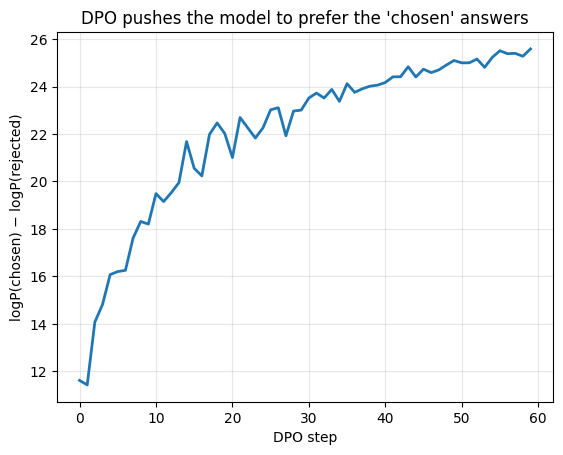

In [5]:
import matplotlib.pyplot as plt
plt.plot(margins, lw=2)
plt.xlabel("DPO step"); plt.ylabel("logP(chosen) − logP(rejected)")
plt.title("DPO pushes the model to prefer the 'chosen' answers")
plt.grid(True, alpha=0.3); plt.show()

margin 一路往上：模型越來越偏好「正確答案」勝過「錯誤答案」——這正是 DPO 在做的事。我們沒訓練任何獎勵模型、也沒跑 RL，只用一個簡單的損失就把模型往人類偏好推了過去。

## 小結 — 你走完了整條路

- **RLHF**：SFT → 獎勵模型 → RL(PPO)，有效但複雜。
- **DPO**：用「偏好配對」+ 一個分類損失，直接對齊偏好，免獎勵模型、免 RL。
- 對齊 = 讓模型不只「會說話」，更「說人類想聽的話」。

從第 01 課的斷詞，到自注意力、Transformer、訓練、KV cache、SFT、DPO——**你從零親手打造並對齊了一個語言模型**。真實的 GPT 只是把每一塊放大幾百萬倍、資料多幾億倍，原理你已經全部掌握了。

## 練習

1. 把 `beta` 調大（如 0.5），margin 成長與穩定性怎麼變？
2. 把偏好改成「偏好較短的回應」，DPO 能學會嗎？（這正是控制模型「話多話少」的做法之一）
3. 回顧整個軌道：哪一塊是讓 GPT「能看懂上下文」的關鍵？哪一塊讓它「聽得懂指令」？

> 🎓 恭喜走完從零打造 LLM 的旅程。下一個前沿是 **AI Agent**——讓模型不只會說話，還會**用工具、做事情**。